### Why K-means alone is not sufficient for clustering?
First, K-means requires the number of clusters (K) to be specified in advance, which can be challenging when the optimal number of clusters is unknown.\
Second, K-means assumes that clusters are spherical and equally sized, which may not always be the case in real-world data.\
Third, K-means is sensitive to outliers, as they can significantly affect the cluster centroids and lead to poor clustering results.\
Lastly, K-means may converge to a local minimum as this does not handle noise well, resulting in suboptimal clustering outcomes depending on the initial placement of centroids.

## Different Clustering Algorithms
1. Distance-based Clustering: K-means, K-medoids, DBSCAN
    - K-means: Partitions data into K clusters by minimizing the sum of squared distances between data points and their assigned cluster centroids.
    - K-medoids: Similar to K-means but uses actual data points (medoids) as cluster centers, making it more robust to outliers.
2. Density-based Clustering: DBSCAN, OPTICS
    - DBSCAN: Groups together points that are closely packed together, marking points in low-density regions as outliers.
    - OPTICS: Similar to DBSCAN but can identify clusters of varying densities and does not require a fixed distance threshold.
3. Structure-based Clustering: Hierarchical Clustering, Agglomerative Clustering
    - Hierarchical Clustering: Builds a hierarchy of clusters either by merging smaller clusters (agglomerative) or by splitting larger clusters (divisive).
    - Agglomerative Clustering: A bottom-up approach where each data point starts as its own cluster and pairs of clusters are merged as one moves up the hierarchy.
4. Model-based Clustering: Gaussian Mixture Models (GMM), Expectation-Maximization (EM) Algorithm
    - GMM: Assumes that the data is generated from a mixture of several Gaussian distributions and estimates the parameters of these distributions.
    - EM Algorithm: An iterative method to find maximum likelihood estimates of parameters in statistical models, often used for clustering with GMM.
5. Graph-based Clustering: Spectral Clustering, Community Detection Algorithms
    - Spectral Clustering: Uses the eigenvalues of a similarity matrix to perform dimensionality reduction before clustering in fewer dimensions.
    - Community Detection Algorithms: Identify clusters in graph data by maximizing modularity or using other criteria to find densely connected subgraphs.

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, marking points in low-density regions as outliers. It requires two parameters: epsilon $(\epsilon)$, which defines the radius of the neighborhood around a point, and minPts, which specifies the minimum number of points required to form a dense region. DBSCAN is effective at discovering clusters of arbitrary shape and is robust to noise, making it suitable for datasets with varying densities. However, it can struggle with clusters of varying densities and may require careful tuning of its parameters for optimal performance.

### Epsilon ($\epsilon$)
Epsilon ($\epsilon$) is a crucial parameter in DBSCAN that defines the radius of the neighborhood around a data point. It determines how close points need to be to each other to be considered part of the same cluster. A smaller $\epsilon$ value will result in more clusters with fewer points, while a larger $\epsilon$ value may lead to fewer clusters with more points. Choosing an appropriate $\epsilon$ is essential for the performance of DBSCAN, and it often requires experimentation or domain knowledge to find the optimal value for a given dataset.

Example: Let, $A(0,0)$, $B(0.1,0.1)$, $C(0.2,0.1)$, $D(3,3)$ and $\epsilon = 0.3$.\
Now calculate the distance between points:
- Distance between A and B: $\sqrt{(0.1-0)^2 +(0.1-0)^2} = \sqrt{0.01 + 0.01} = \sqrt{0.02} \approx 0.141$
- Distance between A and C: $\sqrt{(0.2-0)^2 +(0.1-0)^2} = \sqrt{0.04 + 0.01} = \sqrt{0.05} \approx 0.224$
- Distance between A and D: $\sqrt{(3-0)^2 +(3-0)^2} = \sqrt{9 + 9} = \sqrt{18} \approx 4.243$
- Distance between B and C: $\sqrt{(0.2-0.1)^2 +(0.1-0.1)^2} = \sqrt{0.01 + 0} = \sqrt{0.01} = 0.1$
- Distance between B and D: $\sqrt{(3-0.1)^2 +(3-0.1)^2} = \sqrt{8.41 + 8.41} = \sqrt{16.82} \approx 4.101$
- Distance between C and D: $\sqrt{(3-0.2)^2 +(3-0.1)^2} = \sqrt{7.84 + 8.41} = \sqrt{16.25} \approx 4.031$\
Based on the distances and $\epsilon = 0.3$, points A, B, and C are within the $\epsilon$ radius of each other and form a cluster, while point D is an outlier as it is far from the other points.

### MinPts
MinPts is another important parameter in DBSCAN that specifies the minimum number of points required to form a dense region. A point is considered a core point if it has at least MinPts points (including itself) within its $\epsilon$ neighborhood. If a point is not a core point but is within the $\epsilon$ neighborhood of a core point, it is classified as a border point. The difference between a core point and border point is that core points have enough neighbors to form a dense region aka a cluster, while border points do not, so border points are on the edge of a cluster. Points that are neither core points nor border points are classified as noise or outliers. The choice of MinPts can affect the clustering results, and it often depends on the dimensionality of the data and the expected cluster density.

Example: In previous example, if we set MinPts = 3, then point A is a core point because it has 3 points (A, B, C) within its $\epsilon$ neighborhood. Point B and C are also a core point for the same reason. Point D is an outlier as it does not have any points within its $\epsilon$ neighborhood.

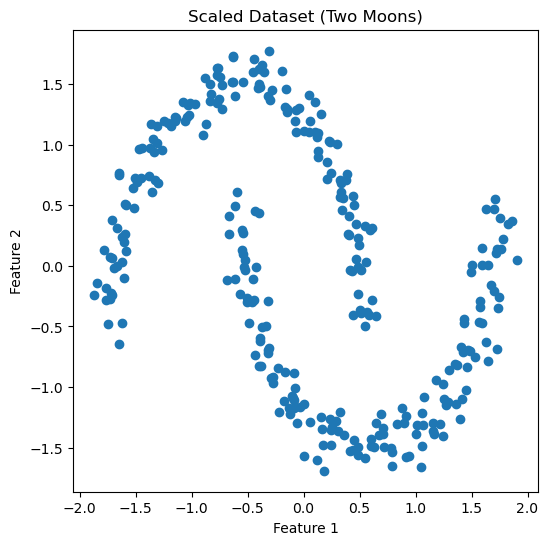

In [13]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=300, noise=0.06, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1])
plt.title("Scaled Dataset (Two Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

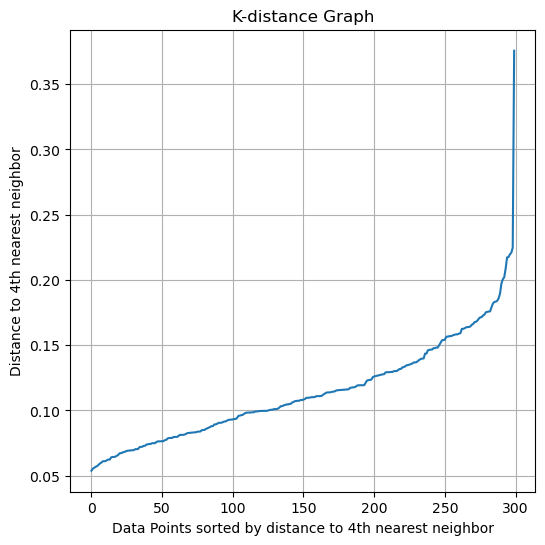

In [ ]:
# Choosing epsilon for DBSCAN(Elbow Method)
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=4)      # Object to find the 4 closest points for every data point in dataset
neighbors_fit = neighbors.fit(X_scaled)     # Fit the model using the scaled data
distances, indices = neighbors_fit.kneighbors(X_scaled)     # Get the distances and indices of the 4 nearest neighbors for each data point
distances = np.sort(distances[:,3], axis=0)     # 4th(index 3) nearest neighbor distance. Every 300 point has a distance to its 4th nearest neighbor. Sort all 300 distances in ascending order. 

plt.figure(figsize=(6,6))
plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Data Points sorted by distance to 4th nearest neighbor")
plt.ylabel("Distance to 4th nearest neighbor")
plt.grid()
plt.show()

# How to choose the epsilon value from the graph? 
# Look for the "elbow" point in the graph where the distance starts to increase more rapidly. Why choose the elbow point? Because it indicates a natural separation between clusters and noise. Points before the elbow are likely to be part of clusters, while points after the elbow are more likely to be noise. In this case, the elbow point is around 0.23, so we can choose epsilon = 0.23 for DBSCAN.

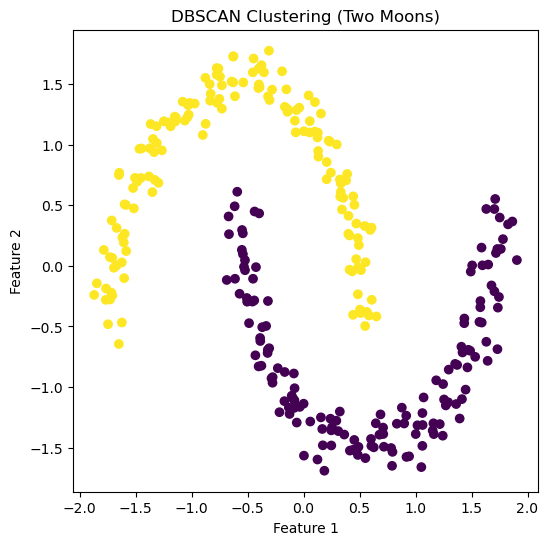

In [8]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.23, min_samples=4)
db_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=db_labels, cmap='viridis')
plt.title("DBSCAN Clustering (Two Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [10]:
print(f"DBSCAN Cluster Labels: {np.unique(db_labels)}")     # 2 clusters (0 and 1) and -1 for noise points

DBSCAN Cluster Labels: [0 1]


# Hierarchical Clustering
Hierarchical clustering is a method of cluster analysis that builds a hierarchy of clusters. It can be performed in two ways: agglomerative (bottom-up) and divisive (top-down). In agglomerative clustering, each data point starts as its own cluster, and pairs of clusters are merged as one moves up the hierarchy. In divisive clustering, all data points start in one cluster, and splits are performed recursively as one moves down the hierarchy. The result is a tree-like structure called a dendrogram, which can be cut at different levels to obtain various numbers of clusters. Hierarchical clustering does not require the number of clusters to be specified in advance and can capture complex relationships between data points, but it can be computationally expensive for large datasets.

## Agglomerative Clustering
Agglomerative clustering is a bottom-up hierarchical clustering method where each data point starts as its own cluster. The algorithm then iteratively merges the closest pairs of clusters based on a chosen distance metric (e.g., Euclidean distance) and linkage criterion (e.g., single linkage, complete linkage, average linkage). This process continues until all data points are merged into a single cluster or until a specified number of clusters is reached. The result is a dendrogram that represents the hierarchical structure of the clusters, which can be cut at different levels to obtain the desired number of clusters. Agglomerative clustering is useful for discovering nested clusters and does not require prior knowledge of the number of clusters, but it can be computationally intensive for large datasets due to the need to calculate distances between all pairs of clusters at each step.

### Linkage Criteria
Linkage criteria are methods used to determine the distance between clusters in hierarchical clustering. The choice of linkage criterion can significantly affect the resulting cluster structure. Common linkage criteria include:
1. Single Linkage: The distance between two clusters is defined as the minimum distance between any pair of points, one from each cluster. This can lead to "chaining" effects where clusters may be elongated and not well-separated.
2. Complete Linkage: The distance between two clusters is defined as the maximum distance between any pair of points, one from each cluster. This tends to produce more compact clusters but can be sensitive to outliers.
3. Average Linkage: The distance between two clusters is defined as the average distance between all pairs of points, one from each cluster. This provides a balance between single and complete linkage and is less sensitive to outliers than complete linkage.
4. Ward's Linkage: The distance between two clusters is defined as the increase in the total within-cluster variance after merging the clusters. This method tends to create clusters of similar size and is effective for minimizing variance within clusters.

### Dendrogram
A dendrogram is a tree-like diagram that represents the hierarchical structure of clusters in hierarchical clustering. It illustrates how clusters are merged or split at each step of the algorithm. The vertical axis of the dendrogram represents the distance or dissimilarity between clusters, while the horizontal axis represents the individual data points or clusters. By cutting the dendrogram at a specific height, the desired number of clusters can be obtained. Dendrograms are useful for visualizing the relationships between clusters and for deciding on the appropriate number of clusters to retain in the analysis.

Dendogram process:
1. Record when ckusters are merged.
2. Records at what distance they are merged.
3. Preserve all intermediate clusters.

Example: Let, we have 4 data points: $A(1,1)$, $B(1,2)$, $C(5,5)$, $D(6,5)$.
1. Start with each point as its own cluster(4 clusters): ${A}$, ${B}$, ${C}$, ${D}$
2. Calculate distances between clusters:
   - Distance between ${A}$ and ${B}$: $\sqrt{(1-1)^2 + (2-1)^2} = 1$
   - Distance between ${A}$ and ${C}$: $\sqrt{(5-1)^2 + (5-1)^2} = \sqrt{16 + 16} = \sqrt{32} \approx 5.66$
   - Distance between ${A}$ and ${D}$: $\sqrt{(6-1)^2 + (5-1)^2} = \sqrt{25 + 16} = \sqrt{41} \approx 6.40$
   - Distance between ${B}$ and ${C}$: $\sqrt{(5-1)^2 + (5-2)^2} = \sqrt{16 + 9} = \sqrt{25} = 5$
   - Distance between ${B}$ and ${D}$: $\sqrt{(6-1)^2 + (5-2)^2} = \sqrt{25 + 9} = \sqrt{34} \approx 5.83$
   - Distance between ${C}$ and ${D}$: $\sqrt{(6-5)^2 + (5-5)^2} = 1$
3. Merge the closest clusters: ${A}$ and ${B}$ are merged to form ${A, B}$. ${C}$ and ${D}$ are merged to form ${C, D}$.
4. Now we have 2 clusters: ${A, B}$ and ${C, D}$.
5. Calculate distance between the new clusters:
   - Distance between ${A, B}$ and ${C, D}$: Using average linkage, we calculate the average distance between all pairs of points in the two clusters:
     - Distance between A and C: $\sqrt{(5-1)^2 + (5-1)^2} = \sqrt{16 + 16} = \sqrt{32} \approx 5.66$
     - Distance between A and D: $\sqrt{(6-1)^2 + (5-1)^2} = \sqrt{25 + 16} = \sqrt{41} \approx 6.40$
     - Distance between B and C: $\sqrt{(5-1)^2 + (5-2)^2} = \sqrt{16 + 9} = \sqrt{25} = 5$
     - Distance between B and D: $\sqrt{(6-1)^2 + (5-2)^2} = \sqrt{25 + 9} = \sqrt{34} \approx 5.83$
   - Average distance: $(5.66 + 6.40 + 5 + 5.83) / 4 \approx 5.72$
6. Final merge: ${A, B}$ and ${C, D}$ are merged to form ${A, B, C, D}$.
7. The dendrogram would show the merging of clusters at distances $1$ (for $A$ and $B$, and for $C$ and $D$) and then at distance $5.72$ for the final merge.
8. By cutting the dendrogram at a distance less than $5.72$, we can retain the two clusters ${A, B}$ and ${C, D}$.

### Comparison 

##### DBSCAN
- Best for noisy data
- Finds arbitrary shaped clusters
- No need to specify cluster count

##### Hierarchical Clustering
- Best for interpretability
- Shows full structure
- Suitable for small to medium datasets

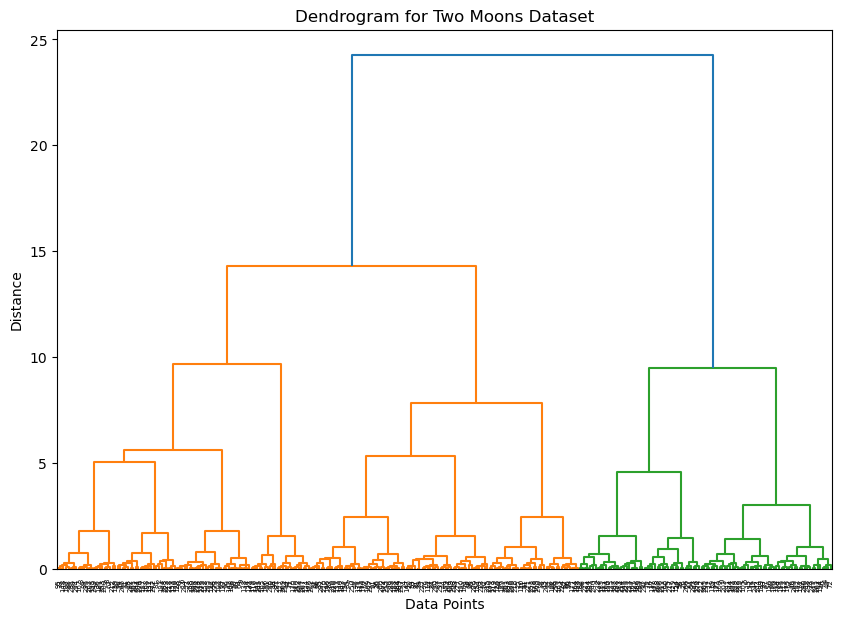

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Dendrogram for Two Moons Dataset")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# From the dendrogram, choose a distance threshold to cut the dendrogram and form clusters. For example, if we choose a distance threshold of 15, we can see that it would result in 2 clusters.

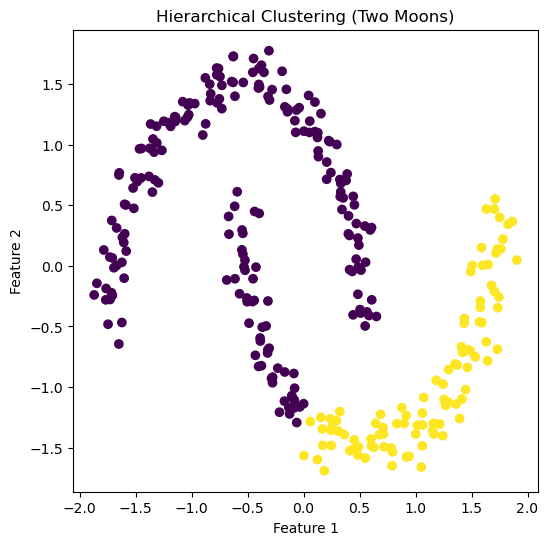

In [19]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hc_labels, cmap='viridis')
plt.title("Hierarchical Clustering (Two Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()